## **About the Dataset**
# Overview
This dataset contains comprehensive, cleaned data representing an e-commerce or quick-commerce retail environment. It provides a 360-degree view of the business operations, combining transactional records, product inventory details, delivery logistics, and customer feedback into a single, unified view suitable for dashboarding and advanced analytics.

Key Data Domains Included:

🛒 Order & Transaction Details: * order_id, order_date, order_total, payment_method, quantity, unit_price, total_price.

Time-based features for trend analysis (hour, day, month, weekday).

👥 Customer Profiling: * customer_id, customer_segment, registration_date, total_orders, avg_order_value.

Geographic data including area and pincode.

📦 Product & Inventory Metrics: * product_id, product_name, category (e.g., Pet Care, Instant Food), brand.

Financial and operational metrics: mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level.

🚚 Logistics & Delivery Performance:

delivery_partner_id, store_id, distance_km.

Time tracking: promised_time, actual_time, delivery_time_minutes.

Delay tracking: is_delayed, delay_minutes, reasons_if_delayed, delay_bucket, delay_category, delivery_status.

⭐ Customer Feedback & Sentiment:

feedback_id, rating, feedback_text.

Categorized feedback metrics: feedback_category, sentiment (e.g., Neutral, Positive, Negative), feedback_date.

📈 Derived Analytical Features:

Pre-calculated metrics for easier analysis, such as delivery_efficiency, order_size, is_peak (peak hour flag), and order_value_bucket.

Potential Use Cases:

Delivery Optimization: Predicting delays and analyzing root causes of late deliveries based on distance, peak times, and partner IDs.

Customer Sentiment Analysis: Correlating customer ratings and NLP sentiment with delivery delays and product categories.

Sales & Inventory Forecasting: Tracking high-demand items, monitoring margin percentages, and optimizing stock levels across different areas.

**Load the Dataset**

In [8]:
import pandas as pd
df = pd.read_csv('/content/FINAL(3)_CLEANED_DASHBOARD_DATA (1).csv')
df.head()

,order_id,customer_id,order_date,order_total,payment_method,delivery_partner_id,store_id,hour,day,month,...,feedback_date,promised_duration_minutes,actual_duration_minutes,delivery_efficiency,order_size,is_peak,delay_category,delivery_status,delay_bucket,order_value_bucket
0,1961864118,30065862,2024-07-17 08:34:01,3197.07,Cash,63230,4771,8,17,7,...,2024-07-17,18.0,13.0,1.384615,3,True,Low Delay,On Time / Early,0-5 min,High
1,1549769649,9573071,2024-05-28 13:14:29,976.55,Cash,14983,7534,13,28,5,...,2024-05-28,11.0,13.0,0.846154,1,False,Low Delay,Delayed,0-5 min,Low
2,9185164487,45477575,2024-09-23 13:07:12,839.05,UPI,39859,9886,13,23,9,...,2024-09-23,18.0,22.0,0.818182,2,False,Low Delay,Delayed,0-5 min,Low
3,9644738826,88067569,2023-11-24 16:16:56,440.23,Card,61497,7917,16,24,11,...,2023-11-24,18.0,17.0,1.058824,1,False,Low Delay,On Time / Early,0-5 min,Low
4,5427684290,83298567,2023-11-20 05:00:39,2526.68,Cash,84315,2741,5,20,11,...,2023-11-20,17.0,18.0,0.944444,2,False,Low Delay,Delayed,0-5 min,Medium


**Total number of rows and columns in the dataset**

In [9]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 5000 rows and 51 columns.


**Column information and Data Types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 51 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   5000 non-null   int64  
 1   customer_id                5000 non-null   int64  
 2   order_date                 5000 non-null   object 
 3   order_total                5000 non-null   float64
 4   payment_method             5000 non-null   object 
 5   delivery_partner_id        5000 non-null   int64  
 6   store_id                   5000 non-null   int64  
 7   hour                       5000 non-null   int64  
 8   day                        5000 non-null   int64  
 9   month                      5000 non-null   int64  
 10  weekday                    5000 non-null   object 
 11  product_id                 5000 non-null   int64  
 12  quantity                   5000 non-null   int64  
 13  unit_price                 5000 non-null   float

**Descriptive Statistics for Numerical Columns**

In [10]:
display(df.describe())

,order_id,customer_id,order_total,delivery_partner_id,store_id,hour,day,month,product_id,quantity,...,avg_order_value,delivery_time_minutes,distance_km,delay_minutes,feedback_id,rating,promised_duration_minutes,actual_duration_minutes,delivery_efficiency,order_size
count,5.000000e+03,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.029129e+09,5.009685e+07,2201.86170,50050.318200,4999.689000,11.522600,15.778400,6.643600,509974.939600,2.006800,...,1092.335244,4.443000,2.718048,5.381800,5.013616e+06,3.34440,14.991400,19.434400,0.894972,2.006800
std,2.863533e+09,2.919082e+07,1303.02438,28802.276922,2886.089242,6.945901,8.784892,3.058701,293678.307475,0.820542,...,523.064064,8.063929,1.290306,7.234756,2.857341e+06,1.18982,3.160336,8.659486,0.336981,0.820542
min,6.046500e+04,3.181300e+04,13.25000,43.000000,1.000000,0.000000,1.000000,1.000000,4452.000000,1.000000,...,200.430000,-5.000000,0.500000,0.000000,9.470000e+02,1.00000,10.000000,5.000000,0.250000,1.000000
25%,2.531421e+09,2.404314e+07,1086.21500,24928.500000,2509.250000,5.750000,8.000000,4.000000,257719.000000,1.000000,...,614.480000,-1.000000,1.590000,0.000000,2.576690e+06,3.00000,12.000000,13.000000,0.647059,1.000000
50%,5.074378e+09,4.997808e+07,2100.69000,50262.500000,4987.000000,12.000000,16.000000,7.000000,540618.000000,2.000000,...,1114.500000,2.000000,2.690000,2.000000,5.005833e+06,4.00000,15.000000,18.000000,0.857143,2.000000
75%,7.488579e+09,7.621215e+07,3156.88250,74478.250000,7500.750000,18.000000,23.000000,9.000000,747801.000000,3.000000,...,1546.232500,8.000000,3.850000,8.000000,7.486478e+06,4.00000,18.000000,24.000000,1.111111,3.000000
max,9.998298e+09,9.989390e+07,6721.46000,99968.000000,9995.000000,23.000000,31.000000,12.000000,993331.000000,3.000000,...,1999.830000,30.000000,5.000000,30.000000,9.999293e+06,5.00000,20.000000,50.000000,2.000000,3.000000


By default, it returns: <br>
* `count` → number of non-null values<br>
* `mean` → average<br>
* `std` → standard deviation<br>
* `min` → minimum value<br>
* `25%` → first quartile<br>
* `50%` → median<br>
* `75%` → third quartile<br>
* `max` → maximum value<br>

**First 5 Rows of the Dataset**

In [11]:
display(df.head())

,order_id,customer_id,order_date,order_total,payment_method,delivery_partner_id,store_id,hour,day,month,...,feedback_date,promised_duration_minutes,actual_duration_minutes,delivery_efficiency,order_size,is_peak,delay_category,delivery_status,delay_bucket,order_value_bucket
0,1961864118,30065862,2024-07-17 08:34:01,3197.07,Cash,63230,4771,8,17,7,...,2024-07-17,18.0,13.0,1.384615,3,True,Low Delay,On Time / Early,0-5 min,High
1,1549769649,9573071,2024-05-28 13:14:29,976.55,Cash,14983,7534,13,28,5,...,2024-05-28,11.0,13.0,0.846154,1,False,Low Delay,Delayed,0-5 min,Low
2,9185164487,45477575,2024-09-23 13:07:12,839.05,UPI,39859,9886,13,23,9,...,2024-09-23,18.0,22.0,0.818182,2,False,Low Delay,Delayed,0-5 min,Low
3,9644738826,88067569,2023-11-24 16:16:56,440.23,Card,61497,7917,16,24,11,...,2023-11-24,18.0,17.0,1.058824,1,False,Low Delay,On Time / Early,0-5 min,Low
4,5427684290,83298567,2023-11-20 05:00:39,2526.68,Cash,84315,2741,5,20,11,...,2023-11-20,17.0,18.0,0.944444,2,False,Low Delay,Delayed,0-5 min,Medium


## **Dashboard 1 — Business Overview:**
Key questions this answer:
1) What is total revenue, AOV, and top categories?
2) Which products and categories drive the most sales?
3) What is the payment method split?
4) How does delivery status affect revenue?
5) What's the margin story?

In [12]:
kpis = {
    'Total Revenue'       : df['total_price'].sum(),
    'Total Orders'        : df['order_id'].nunique(),
    'Avg Order Value'     : df['order_total'].mean(),
    'Avg Items per Order' : df['order_size'].mean(),
    'Total Products Sold' : df['quantity'].sum(),
}
for k, v in kpis.items():
    print(f"{k}: {v:,.2f}")

Total Revenue: 4,972,415.43
Total Orders: 5,000.00
Avg Order Value: 2,201.86
Avg Items per Order: 2.01
Total Products Sold: 10,034.00


Revenue by Category

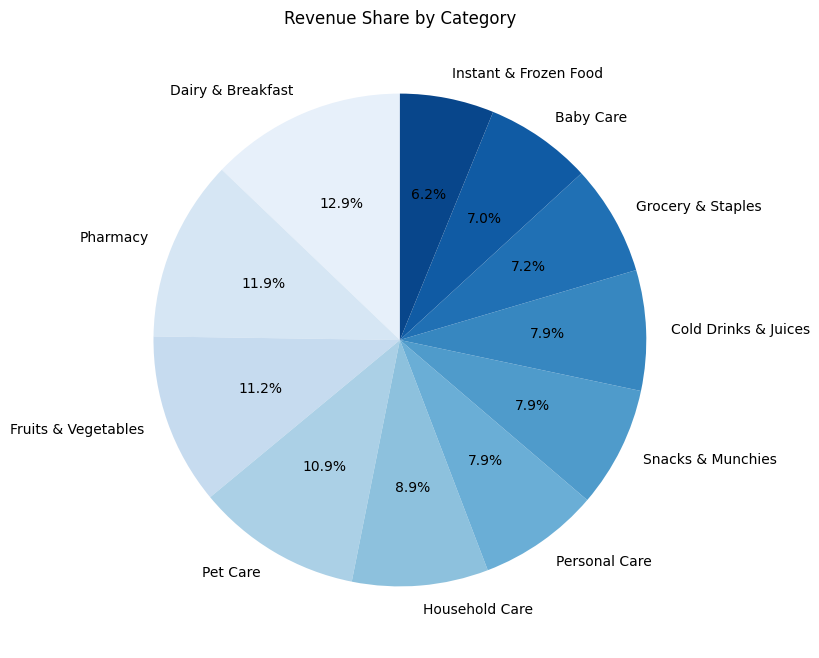

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_revenue = df.groupby('category').agg(
    revenue      = ('total_price', 'sum'),
    orders       = ('order_id', 'nunique'),
    avg_margin   = ('margin_percentage', 'mean')
).reset_index().sort_values('revenue', ascending=False)

# Pie chart for dashboard
plt.figure(figsize=(10,8))
plt.pie(cat_revenue['revenue'], labels=cat_revenue['category'],
        autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('Blues', len(cat_revenue)))
plt.title('Revenue Share by Category')
plt.savefig('revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 Products

/tmp/ipykernel_1113/1701857040.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='revenue', y='product_name', palette='Blues_d')


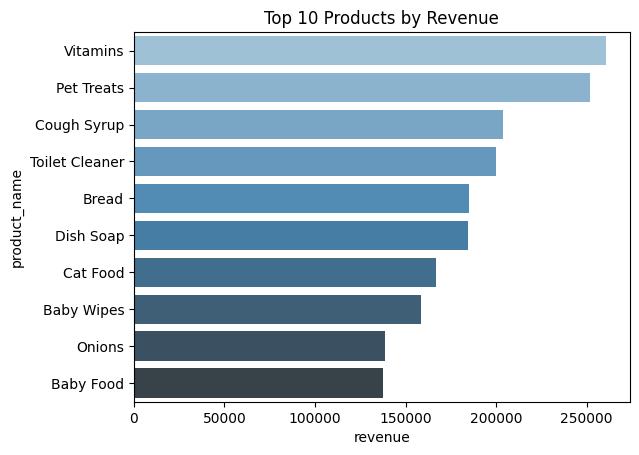

In [19]:
top_products = df.groupby('product_name').agg(
    revenue     = ('total_price', 'sum'),
    qty_sold    = ('quantity', 'sum'),
    order_count = ('order_id', 'nunique')
).reset_index().sort_values('revenue', ascending=False).head(10)

sns.barplot(data=top_products, x='revenue', y='product_name', palette='Blues_d')
plt.title('Top 10 Products by Revenue')
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')

Payment Method Split

payment_method
Card      25.70
Cash      25.14
Wallet    24.88
UPI       24.28
Name: proportion, dtype: float64


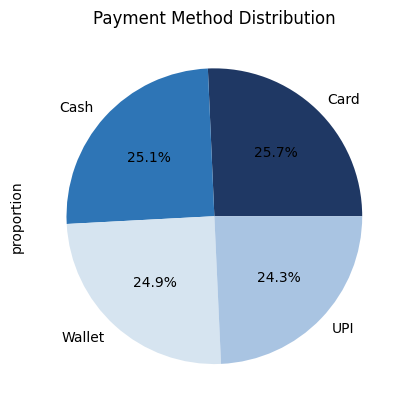

In [20]:
payment = df['payment_method'].value_counts(normalize=True) * 100
print(payment)

payment.plot(kind='pie', autopct='%1.1f%%', title='Payment Method Distribution',
             colors=['#1F3864','#2E75B6','#D6E4F0','#A9C4E2'])
plt.savefig('payment_split.png', dpi=150)

Revenue by Delivery Status

In [21]:
df.groupby('delivery_status')[['order_total','total_price']].mean()

,order_total,total_price
delivery_status,,
Delayed,2207.279396,986.920684
On Time / Early,2193.037292,1006.800815


Order Value Segments

In [22]:
# Create if not already done
df['order_value_segment'] = pd.cut(
    df['order_total'],
    bins=[0, 500, 2000, 5000, df['order_total'].max()],
    labels=['Low (<500)', 'Medium (500-2K)', 'High (2K-5K)', 'Premium (5K+)']
)

seg = df.groupby('order_value_segment').agg(
    count   = ('order_id','nunique'),
    revenue = ('order_total','sum')
).reset_index()
print(seg)

  order_value_segment  count     revenue
0          Low (<500)    456   125363.14
1     Medium (500-2K)   1916  2388873.69
2        High (2K-5K)   2537  8003680.69
3       Premium (5K+)     91   491390.98


/tmp/ipykernel_1113/4083466199.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = df.groupby('order_value_segment').agg(


## **Dashboard 2 — Operations (Delivery & Orders)**
Key questions this dashboard answer:
1) How often are deliveries late, and by how much?
2) Which hours/days have the worst delays?
3) Which delivery partners perform best/worst?
4) Which stores are slowest?
5) Does peak hour actually make things worse?



Delivery Performance Overview

In [23]:
# Overall delay stats
print("Average delay:", df['delay_minutes'].mean())
print("% of delayed orders:", df['is_delayed'].mean() * 100)
print("Average efficiency:", df['delivery_efficiency'].mean())

# Delay category breakdown
df['delay_category'].value_counts(normalize=True) * 100

Average delay: 5.3818
% of delayed orders: 61.96
Average efficiency: 0.8949723850338375


,proportion
delay_category,
Low Delay,69.40
Medium Delay,20.74
High Delay,9.86


 Delay by Hour (Peak vs Off-Peak)

/tmp/ipykernel_1113/2452835986.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_delay, x='hour', y='delay_minutes', palette='Blues_d')


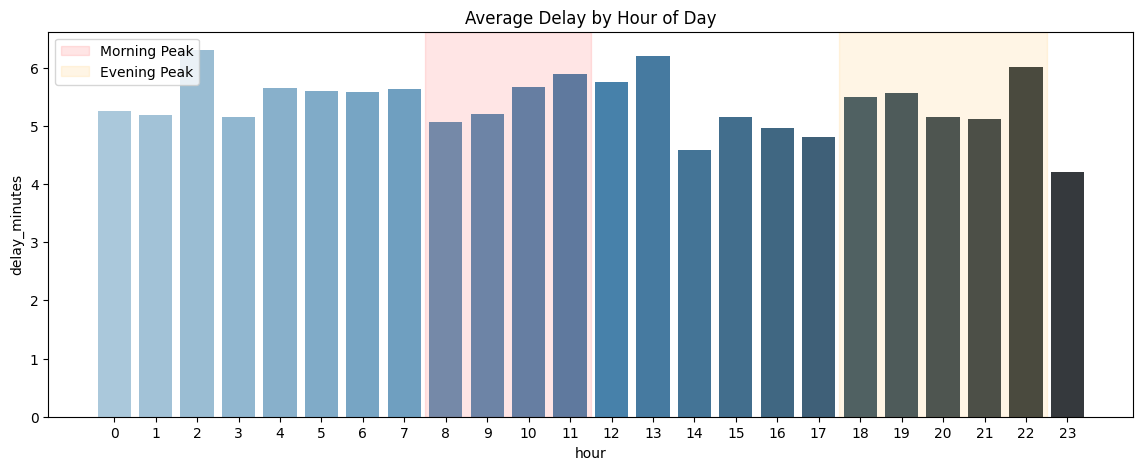

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

hourly_delay = df.groupby('hour')['delay_minutes'].mean().reset_index()

plt.figure(figsize=(14,5))
sns.barplot(data=hourly_delay, x='hour', y='delay_minutes', palette='Blues_d')
plt.title('Average Delay by Hour of Day')
plt.axvspan(7.5, 11.5, alpha=0.1, color='red', label='Morning Peak')
plt.axvspan(17.5, 22.5, alpha=0.1, color='orange', label='Evening Peak')
plt.legend()
plt.savefig('delay_by_hour.png', dpi=150)
plt.show()

Delivery Partner Performance

In [25]:
partner_perf = df.groupby('delivery_partner_id').agg(
    avg_delay        = ('delay_minutes', 'mean'),
    avg_efficiency   = ('delivery_efficiency', 'mean'),
    total_orders     = ('order_id', 'count'),
    delayed_pct      = ('is_delayed', 'mean')
).reset_index()

# Top 10 worst partners
partner_perf.sort_values('avg_delay', ascending=False).head(10)

,delivery_partner_id,avg_delay,avg_efficiency,total_orders,delayed_pct
18,246,30.0,0.347826,1,1.0
4958,98726,30.0,0.268293,1,1.0
4637,92844,30.0,0.302326,1,1.0
4807,95971,30.0,0.387755,1,1.0
4702,93983,30.0,0.268293,1,1.0
4716,94212,30.0,0.347826,1,1.0
3287,65591,30.0,0.375000,1,1.0
3251,65001,30.0,0.400000,1,1.0
4341,86820,30.0,0.318182,1,1.0
4583,91747,30.0,0.250000,1,1.0


Store Performance

In [26]:
store_perf = df.groupby('store_id').agg(
    avg_delay      = ('delay_minutes', 'mean'),
    delayed_pct    = ('is_delayed', 'mean'),
    total_orders   = ('order_id', 'count')
).reset_index()

store_perf.sort_values('delayed_pct', ascending=False).head(10)

,store_id,avg_delay,delayed_pct,total_orders
4999,9995,14.0,1.0,1
4998,9991,4.0,1.0,1
4997,9989,18.0,1.0,1
4978,9944,5.0,1.0,1
4977,9939,1.0,1.0,1
4976,9938,8.0,1.0,1
4974,9933,6.0,1.0,1
4973,9932,4.0,1.0,1
4972,9927,12.0,1.0,1
4971,9924,9.0,1.0,1


Peak vs Off-Peak Comparison

In [27]:
peak_compare = df.groupby('is_peak').agg(
    avg_delay        = ('delay_minutes', 'mean'),
    avg_efficiency   = ('delivery_efficiency', 'mean'),
    avg_actual_time  = ('actual_duration_minutes', 'mean'),
    order_count      = ('order_id', 'count')
).reset_index()

peak_compare['is_peak'] = peak_compare['is_peak'].map({True:'Peak', False:'Off-Peak'})
print(peak_compare)

    is_peak  avg_delay  avg_efficiency  avg_actual_time  order_count
0  Off-Peak   5.341244        0.896470        19.394804         3118
1      Peak   5.448990        0.892491        19.500000         1882


Orders by Day/Month Trend

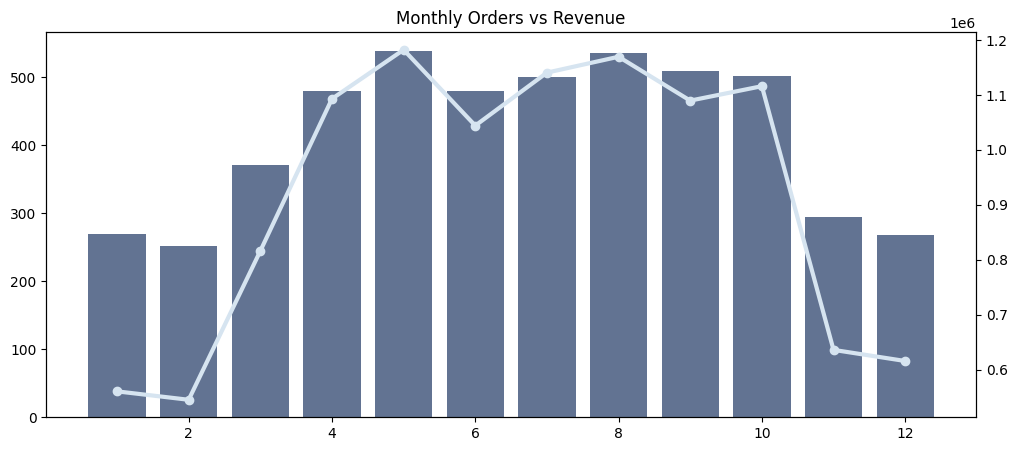

In [28]:
monthly_orders = df.groupby('month').agg(
    orders  = ('order_id', 'nunique'),
    revenue = ('order_total', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()
ax1.bar(monthly_orders['month'], monthly_orders['orders'], color='#1F3864', alpha=0.7)
ax2.plot(monthly_orders['month'], monthly_orders['revenue'], color='#D6E4F0', linewidth=3, marker='o')
plt.title('Monthly Orders vs Revenue')
plt.savefig('monthly_trends.png', dpi=150)
plt.show()

## **Dashboard 3 — Customer Analysis**
Key questions this dashboard answer:
1) How are customers segmented (Premium, Regular, New, Inactive)?
2) Which segment generates the most revenue?
3) What is the sentiment/rating distribution?
4) What are common feedback categories?
5) Where are customers located (area-wise)?


Customer Segment Revenue

In [29]:
seg_analysis = df.groupby('customer_segment').agg(
    customers    = ('customer_id', 'nunique'),
    total_revenue= ('order_total', 'sum'),
    avg_order    = ('order_total', 'mean'),
    avg_rating   = ('rating', 'mean'),
    avg_delay    = ('delay_minutes', 'mean')
).reset_index()

print(seg_analysis)

  customer_segment  customers  total_revenue    avg_order  avg_rating  \
0         Inactive        518     2591975.65  2178.130798    3.366387   
1              New        530     2795854.48  2287.933290    3.339607   
2          Premium        550     2731329.71  2154.045513    3.320978   
3          Regular        574     2890148.66  2189.506561    3.351515   

   avg_delay  
0   5.288235  
1   5.523732  
2   5.421136  
3   5.296970  


Rating Distribution

/tmp/ipykernel_1113/4281067320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_dist.index, y=rating_dist.values, palette='Blues_d')


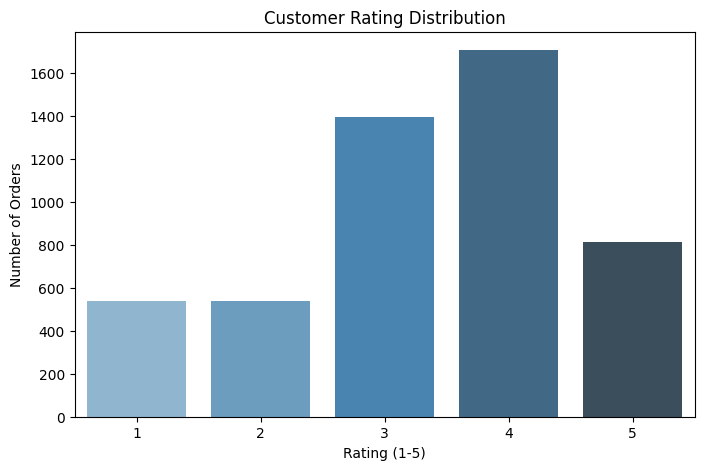

In [30]:
rating_dist = df['rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=rating_dist.index, y=rating_dist.values, palette='Blues_d')
plt.title('Customer Rating Distribution')
plt.xlabel('Rating (1-5)')
plt.ylabel('Number of Orders')
plt.savefig('rating_distribution.png', dpi=150)

 Sentiment Analysis

In [31]:
sentiment = df['sentiment'].value_counts(normalize=True) * 100
print(sentiment)

# Sentiment vs Avg Rating
df.groupby('sentiment')['rating'].mean()

# Sentiment vs Delay
df.groupby('sentiment')['delay_minutes'].mean()

sentiment
Neutral     34.76
Negative    32.84
Positive    32.40
Name: proportion, dtype: float64


,delay_minutes
sentiment,
Negative,5.516443
Neutral,5.336594
Positive,5.293827


Feedback Category Breakdown

feedback_category
Delivery            1271
Customer Service    1266
Product Quality     1250
App Experience      1213
Name: count, dtype: int64


/tmp/ipykernel_1113/2575744280.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feedback_cat.values, y=feedback_cat.index, palette='Blues_d')


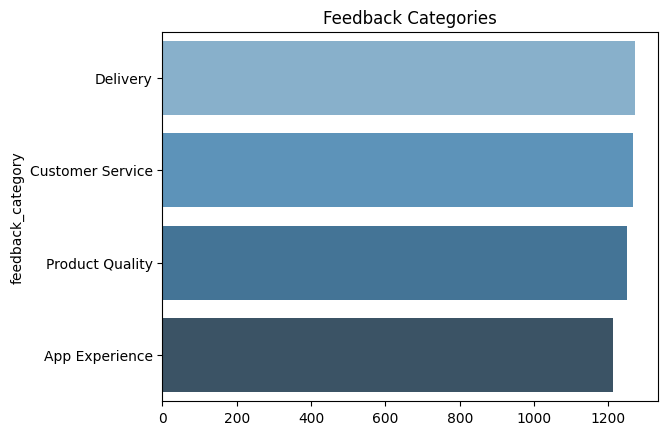

In [32]:
feedback_cat = df['feedback_category'].value_counts()
print(feedback_cat)

sns.barplot(x=feedback_cat.values, y=feedback_cat.index, palette='Blues_d')
plt.title('Feedback Categories')
plt.savefig('feedback_categories.png', dpi=150, bbox_inches='tight')

Top Customer Areas


In [33]:
area_analysis = df.groupby('area').agg(
    orders    = ('order_id', 'nunique'),
    revenue   = ('order_total', 'sum'),
    avg_delay = ('delay_minutes', 'mean')
).reset_index().sort_values('orders', ascending=False).head(15)

print(area_analysis)

            area  orders   revenue  avg_delay
218         Orai      44  99590.96   6.681818
80       Deoghar      40  95386.05   4.650000
97   Gandhinagar      37  82273.95   6.081081
207      Nandyal      36  83281.10   3.888889
248       Ratlam      35  67426.31   5.000000
34      Bathinda      34  63497.76   5.676471
100    Ghaziabad      32  72599.85   6.968750
301      Udaipur      31  67184.59   5.935484
52        Bhopal      31  78854.32   5.193548
288       Tezpur      30  65430.40   5.333333
4     Ahmednagar      30  72233.14   4.200000
130        Jalna      30  69086.31   3.933333
126     Jabalpur      30  70135.67   5.866667
158   Kishanganj      29  62790.22   2.793103
141       Kadapa      28  50179.27   5.464286


Does Delay Kill Ratings? (Key Insight)

/tmp/ipykernel_1113/3896591964.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_rating = df.groupby('delay_bucket')['rating'].mean()


delay_bucket
On Time         3.347003
Low Delay       3.315051
Medium Delay    3.392478
High Delay      3.326572
Name: rating, dtype: float64


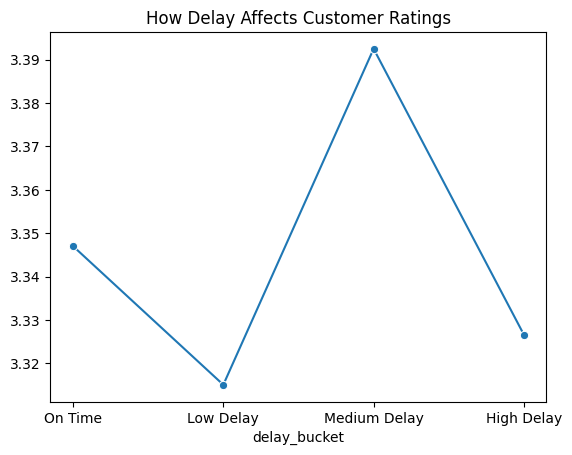

In [34]:
# Bin delays and see average rating
df['delay_bucket'] = pd.cut(df['delay_minutes'],
    bins=[-1,0,5,15,100],
    labels=['On Time','Low Delay','Medium Delay','High Delay'])

delay_rating = df.groupby('delay_bucket')['rating'].mean()
print(delay_rating)

# This will likely show: On Time -> 4.x, High Delay -> 2.x
sns.lineplot(x=delay_rating.index, y=delay_rating.values, marker='o')
plt.title('How Delay Affects Customer Ratings')
plt.savefig('delay_vs_rating.png', dpi=150)